# Final Score 0.94402: Detection + TTA Pipeline

이 노트북은 최종 제출에 사용한 detection/TTA 추론 파이프라인입니다.

| 단계 | 모델 | 역할 |
|---|---|---|
| Det-A | Grounding DINO Base | 질문 키워드 기반 open-set 탐지 |
| Det-B | Florence-2-large-ft | 범용 전체 물체 탐지 |
| VQA-A | Qwen3-VL-32B | 원본+crop 추론 |
| VQA-B | Qwen3.5-27B | 보조 추론 |


## 1. 환경

In [6]:
!pip install -q --upgrade pip
!pip install -q "transformers @ git+https://github.com/huggingface/transformers.git@main"
!pip install -q --upgrade accelerate bitsandbytes peft
!pip install -q qwen-vl-utils

import torch
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}, VRAM: {p.total_memory/1024**3:.1f}GB")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
PyTorch: 2.10.0+cu128, CUDA: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition, VRAM: 95.0GB


## 2. Drive & 경로

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
DATA_ROOT = "/content/drive/MyDrive/Colab Notebooks/"
TRAIN_CSV = os.path.join(DATA_ROOT, "train.csv")
TEST_CSV  = os.path.join(DATA_ROOT, "test.csv")
IMAGE_ROOT = DATA_ROOT
CKPT_32B = "/content/drive/MyDrive/checkpoint_best"  # Qwen3-VL-32B LoRA

for n,p in [("Train",TRAIN_CSV),("Test",TEST_CSV),("VQA-A ckpt",CKPT_32B)]:
    print(f"{'✅' if os.path.exists(p) else '❌'} {n}: {p}")

✅ Train: /content/drive/MyDrive/Colab Notebooks/train.csv
✅ Test: /content/drive/MyDrive/Colab Notebooks/test.csv
✅ VQA-A ckpt: /content/drive/MyDrive/checkpoint_best


## 3. 공통

In [9]:
import os, re, random, gc, math, pickle
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageOps
from collections import Counter
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

Image.MAX_IMAGE_PIXELS = None
device = "cuda"
SEED = 42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

MODEL_A_ID = "Qwen/Qwen3-VL-32B-Instruct"
MODEL_B_ID = "Qwen/Qwen3.5-27B"
MAX_NEW_TOKENS = 2

# 가중치 설정
W_VQA_A = 1.0   # Qwen3-VL-32B (도메인 fine-tuned)
W_VQA_B = 0.7   # Qwen3.5-27B  (범용, 더 강력한 vision)
W_TTA   = 0.5   # TTA (좌우반전) 가중치 (원본 대비)

## 4. 데이터 로드

In [10]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)

def fix_path(p):
    if os.path.isabs(p) and os.path.exists(p): return p
    c = os.path.join(DATA_ROOT, p)
    return c if os.path.exists(c) else p

train_df["path"] = train_df["path"].astype(str).apply(fix_path)
test_df["path"]  = test_df["path"].astype(str).apply(fix_path)
print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Train: 5073, Test: 5074


## 5. Phase 1 — Detection (Grounding DINO + Florence-2) → 크롭 캐싱

전체 테스트 이미지에 대해 크롭을 미리 생성하고 저장합니다.
Detection 모델은 이 단계 후 언로드합니다.

In [11]:
# ===== Grounding DINO =====
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

gd_proc = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
gd_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-base"
).to(device).eval()
print(f"✅ Grounding DINO loaded")

# ===== Florence-2 =====
from transformers import Florence2ForConditionalGeneration

fl_proc = AutoProcessor.from_pretrained("florence-community/Florence-2-large-ft")
fl_model = Florence2ForConditionalGeneration.from_pretrained(
    "florence-community/Florence-2-large-ft",
    torch_dtype=torch.bfloat16, device_map="auto",
).eval()
print(f"✅ Florence-2 loaded")

preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/917 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

✅ Florence-2 loaded


In [12]:
# ===== 키워드 추출 + Detection 함수 =====
KR_EN = {
    "플라스틱":"plastic bottle. plastic container", "유리":"glass bottle. glass",
    "금속":"metal can. metal", "캔":"metal can. aluminum can",
    "종이":"paper. cardboard box", "비닐":"plastic bag. vinyl bag",
    "스티로폼":"styrofoam. foam", "페트":"PET bottle. plastic bottle",
    "텀블러":"tumbler. cup", "병":"bottle", "컵":"cup. paper cup",
    "상자":"box. package", "봉지":"bag. plastic bag", "뚜껑":"cap. lid",
    "라벨":"label", "과자":"snack package. food wrapper",
    "음료":"beverage bottle. drink", "우유":"milk carton",
    "빨대":"straw", "용기":"container", "포장":"packaging. wrapper",
    "박스":"cardboard box", "팩":"carton. pack",
}

def question_to_keywords(question):
    kws = [en for kr, en in KR_EN.items() if kr in question]
    return ". ".join(kws) if kws else "recyclable item. waste. object"

def detect_grounding_dino(image, question, box_th=0.25, text_th=0.20):
    keywords = question_to_keywords(question)
    text_labels = [keywords.split(". ")]
    inputs = gd_proc(images=image, text=text_labels, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = gd_model(**inputs)
    results = gd_proc.post_process_grounded_object_detection(
        outputs, inputs.input_ids,
        threshold=box_th, text_threshold=text_th,
        target_sizes=[(image.height, image.width)],
    )[0]
    det_labels = results.get("text_labels", results.get("labels", []))
    dets = []
    for box, score, label in zip(results["boxes"], results["scores"], det_labels):
        dets.append({"box": box.tolist(), "score": score.item(), "label": label, "src": "gd"})
    return dets

def detect_florence2(image):
    inputs = fl_proc(text="<OD>", images=image, return_tensors="pt").to(fl_model.device, torch.bfloat16)
    with torch.no_grad():
        gen_ids = fl_model.generate(**inputs, max_new_tokens=1024, num_beams=3, do_sample=False)
    gen_text = fl_proc.batch_decode(gen_ids, skip_special_tokens=False)[0]
    parsed = fl_proc.post_process_generation(gen_text, task="<OD>", image_size=(image.width, image.height))
    dets = []
    if "<OD>" in parsed:
        r = parsed["<OD>"]
        for box, label in zip(r.get("bboxes",[]), r.get("labels",[])):
            dets.append({"box": list(box), "score": 0.80, "label": label, "src": "fl"})
    return dets

def iou(b1, b2):
    x1=max(b1[0],b2[0]); y1=max(b1[1],b2[1]); x2=min(b1[2],b2[2]); y2=min(b1[3],b2[3])
    inter=max(0,x2-x1)*max(0,y2-y1)
    union=(b1[2]-b1[0])*(b1[3]-b1[1])+(b2[2]-b2[0])*(b2[3]-b2[1])-inter
    return inter/union if union>0 else 0

def get_best_crop(image, question, margin=0.15):
    gd = detect_grounding_dino(image, question)
    fl = detect_florence2(image)
    merged = []
    for d in sorted(gd + fl, key=lambda x: -x["score"]):
        if not any(iou(d["box"], m["box"]) > 0.5 for m in merged):
            merged.append(d)
    if not merged:
        return None
    best = merged[0]
    x1,y1,x2,y2 = best["box"]
    w,h = image.width, image.height
    bw,bh = x2-x1, y2-y1
    mx,my = bw*margin, bh*margin
    cx1,cy1 = max(0,int(x1-mx)), max(0,int(y1-my))
    cx2,cy2 = min(w,int(x2+mx)), min(h,int(y2+my))
    if (cx2-cx1)<w*0.05 or (cy2-cy1)<h*0.05:
        return None
    return image.crop((cx1,cy1,cx2,cy2))

print("✅ Detection 함수 정의 완료")

✅ Detection 함수 정의 완료


In [13]:
# ===== 전체 테스트 크롭 생성 + 캐싱 =====
CROP_CACHE = {}  # idx → PIL Image or None

for i in tqdm(range(len(test_df)), desc="Generating crops"):
    row = test_df.iloc[i]
    if not os.path.exists(row["path"]):
        CROP_CACHE[i] = None
        continue
    img = Image.open(row["path"]).convert("RGB")
    CROP_CACHE[i] = get_best_crop(img, str(row["question"]))

crop_count = sum(1 for v in CROP_CACHE.values() if v is not None)
print(f"✅ Crops generated: {crop_count}/{len(test_df)} ({crop_count/len(test_df)*100:.1f}%)")

# Detection 모델 언로드
del gd_model, gd_proc, fl_model, fl_proc
torch.cuda.empty_cache(); gc.collect()
print("✅ Detection 모델 언로드 완료")

Generating crops:   0%|          | 0/5074 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:96: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


✅ Crops generated: 5010/5074 (98.7%)
✅ Detection 모델 언로드 완료


## 6. 공통 추론 유틸

프롬프트, TTA, logit 추출 함수

In [24]:
def classify_qtype(q):
    for p in [r'몇\s*개',r'몇\s*병',r'몇\s*캔',r'개수',r'수량',r'총\s*몇',r'몇\s*가지',r'몇\s*종류']:
        if re.search(p, q): return "counting"
    for p in [r'재질',r'소재',r'재료',r'무엇으로\s*만들']:
        if re.search(p, q): return "material"
    return "general"

SYSTEM = (
    "You are an expert recycling visual analysis AI. "
    "Examine all images carefully. "
    "Return exactly one lowercase letter (a, b, c, or d). No explanation."
)

def build_user_text(q, a, b, c, d, has_crop):
    qt = classify_qtype(q)
    hints = {"counting": "Count items in both overview and close-up.",
             "material": "Identify material texture in the close-up.",
             "general": "Use the close-up to examine details."}
    hint = hints[qt] if has_crop else ""
    return f"{hint}\nQUESTION: {q}\na) {a}\nb) {b}\nc) {c}\nd) {d}\nAnswer:"

def resize_vqa(img, max_size=768):
    img = img.copy(); img.thumbnail((max_size, max_size), Image.LANCZOS); return img

def extract_probs(out, inputs, processor):
    """generate 출력에서 a/b/c/d softmax 확률 추출"""
    if not out.scores or len(out.scores) == 0:
        return None
    logits = out.scores[0][0]
    cids = {}
    for ch in 'abcd':
        ids = processor.tokenizer.encode(ch, add_special_tokens=False)
        if ids: cids[ch] = ids[-1]
    if len(cids) != 4:
        return None
    lv = torch.tensor([logits[cids[ch]].item() for ch in 'abcd'], dtype=torch.float32)
    return torch.softmax(lv, dim=0)

def probs_to_answer(probs):
    if probs is None:
        return random.choice(['a','b','c','d']), 0.25
    idx = probs.argmax().item()
    return 'abcd'[idx], probs[idx].item()

print("✅ 유틸 정의 완료")

✅ 유틸 정의 완료


## 7. Phase 2 — VQA-A: Qwen3-VL-32B (LoRA) + TTA

원본 + 좌우반전 → 각각 (원본이미지, 크롭이미지) 멀티이미지 추론
→ 2회 logit 수집

In [15]:
from transformers import AutoProcessor as AP
from transformers import Qwen3VLForConditionalGeneration
from peft import PeftModel

print("📥 Loading VQA-A: Qwen3-VL-32B + LoRA...")
base_a = Qwen3VLForConditionalGeneration.from_pretrained(
    MODEL_A_ID, torch_dtype=torch.bfloat16,
    trust_remote_code=True, low_cpu_mem_usage=True,
)
vqa_a = PeftModel.from_pretrained(base_a, CKPT_32B, local_files_only=True)
vqa_a = vqa_a.to(device).eval()
proc_a = AP.from_pretrained(MODEL_A_ID, trust_remote_code=True)
print("✅ VQA-A loaded")

📥 Loading VQA-A: Qwen3-VL-32B + LoRA...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1058 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✅ VQA-A loaded


In [16]:
def infer_vqa_a(image, crop, question, a, b, c, d, processor, model):
    """Qwen3-VL-32B 단일 추론 → probs 반환"""
    has_crop = crop is not None
    user_text = build_user_text(question, a, b, c, d, has_crop)

    imgs = [resize_vqa(image)]
    user_content = [{"type":"image","image":imgs[0]}]
    if has_crop:
        cr = resize_vqa(crop)
        imgs.append(cr)
        user_content.append({"type":"image","image":cr})
    user_content.append({"type":"text","text":user_text})

    messages = [
        {"role":"system","content":[{"type":"text","text":SYSTEM}]},
        {"role":"user","content":user_content},
    ]
    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[text], images=imgs, return_tensors="pt")
    inputs = {k:v.to(device) for k,v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            output_scores=True, return_dict_in_generate=True,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
    return extract_probs(out, inputs, processor)

# ===== VQA-A TTA 추론 =====
all_probs_a = []  # list of (probs_orig, probs_flip)

for i in tqdm(range(len(test_df)), desc="VQA-A TTA"):
    row = test_df.iloc[i]
    if not os.path.exists(row["path"]):
        all_probs_a.append((None, None)); continue

    image = Image.open(row["path"]).convert("RGB")
    crop = CROP_CACHE.get(i)
    q,a,b,c,d = str(row["question"]),str(row["a"]),str(row["b"]),str(row["c"]),str(row["d"])

    # 원본
    p_orig = infer_vqa_a(image, crop, q, a, b, c, d, proc_a, vqa_a)

    # TTA: 좌우반전
    image_flip = ImageOps.mirror(image)
    crop_flip = ImageOps.mirror(crop) if crop else None
    p_flip = infer_vqa_a(image_flip, crop_flip, q, a, b, c, d, proc_a, vqa_a)

    all_probs_a.append((p_orig, p_flip))

    if i < 3:
        ans, conf = probs_to_answer(p_orig)
        print(f"  [{i}] VQA-A → {ans} ({conf:.3f})")

print(f"✅ VQA-A TTA 완료: {len(all_probs_a)}")

# 언로드
del vqa_a, base_a, proc_a
torch.cuda.empty_cache(); gc.collect()
print("✅ VQA-A 언로드")

VQA-A TTA:   0%|          | 0/5074 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


  [0] VQA-A → d (0.940)
  [1] VQA-A → b (0.922)
  [2] VQA-A → c (0.958)
✅ VQA-A TTA 완료: 5074
✅ VQA-A 언로드


In [25]:
submission = pd.DataFrame({"id": test_df["id"], "answer": ans})
sub_path = os.path.join(DATA_ROOT, "submission_final_tta_ensemble.csv")
submission.to_csv(sub_path, index=False)
print(f"✅ Saved: {sub_path}")
print(submission["answer"].value_counts().sort_index())
print(f"Total: {len(submission)}")

✅ Saved: /content/drive/MyDrive/Colab Notebooks/submission_final_tta_ensemble.csv
answer
c    5074
Name: count, dtype: int64
Total: 5074


## 8. Phase 3 — VQA-B: Qwen3.5-27B + TTA

동일한 이미지/크롭으로 Qwen3.5-27B 추론.
Thinking OFF (`enable_thinking=False`)

In [17]:
from transformers import AutoModelForImageTextToText

print("📥 Loading VQA-B: Qwen3.5-27B...")
vqa_b = AutoModelForImageTextToText.from_pretrained(
    MODEL_B_ID, torch_dtype=torch.bfloat16,
    device_map="auto", trust_remote_code=True, low_cpu_mem_usage=True,
).eval()
proc_b = AP.from_pretrained(MODEL_B_ID, trust_remote_code=True)
print(f"✅ VQA-B loaded ({sum(p.numel() for p in vqa_b.parameters())/1e9:.1f}B params)")

📥 Loading VQA-B: Qwen3.5-27B...


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

✅ VQA-B loaded (27.4B params)


In [18]:
def infer_vqa_b(image, crop, question, a, b, c, d, processor, model):
    """Qwen3.5-27B 단일 추론 → probs. Thinking OFF."""
    has_crop = crop is not None
    user_text = build_user_text(question, a, b, c, d, has_crop)

    imgs = [resize_vqa(image)]
    user_content = [{"type":"image","image":imgs[0]}]
    if has_crop:
        cr = resize_vqa(crop)
        imgs.append(cr)
        user_content.append({"type":"image","image":cr})
    user_content.append({"type":"text","text":user_text})

    messages = [
        {"role":"system","content":[{"type":"text","text":SYSTEM}]},
        {"role":"user","content":user_content},
    ]

    # ⚠️ Thinking OFF
    try:
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
            enable_thinking=False,
        )
    except TypeError:
        text = processor.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=True,
        )

    inputs = processor(text=[text], images=imgs, return_tensors="pt")
    inputs = {k:v.to(model.device) for k,v in inputs.items()}

    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            output_scores=True, return_dict_in_generate=True,
            eos_token_id=processor.tokenizer.eos_token_id,
        )
    return extract_probs(out, inputs, processor)

# ===== VQA-B TTA 추론 =====
all_probs_b = []

for i in tqdm(range(len(test_df)), desc="VQA-B TTA"):
    row = test_df.iloc[i]
    if not os.path.exists(row["path"]):
        all_probs_b.append((None, None)); continue

    image = Image.open(row["path"]).convert("RGB")
    crop = CROP_CACHE.get(i)
    q,a,b,c,d = str(row["question"]),str(row["a"]),str(row["b"]),str(row["c"]),str(row["d"])

    # 원본
    p_orig = infer_vqa_b(image, crop, q, a, b, c, d, proc_b, vqa_b)

    # TTA: 좌우반전
    image_flip = ImageOps.mirror(image)
    crop_flip = ImageOps.mirror(crop) if crop else None
    p_flip = infer_vqa_b(image_flip, crop_flip, q, a, b, c, d, proc_b, vqa_b)

    all_probs_b.append((p_orig, p_flip))

    if i < 3:
        ans, conf = probs_to_answer(p_orig)
        print(f"  [{i}] VQA-B → {ans} ({conf:.3f})")

print(f"✅ VQA-B TTA 완료: {len(all_probs_b)}")

del vqa_b, proc_b
torch.cuda.empty_cache(); gc.collect()
print("✅ VQA-B 언로드")

VQA-B TTA:   0%|          | 0/5074 [00:00<?, ?it/s]

  [0] VQA-B → d (0.922)
  [1] VQA-B → b (0.737)
  [2] VQA-B → c (0.989)
✅ VQA-B TTA 완료: 5074
✅ VQA-B 언로드


## 9. 가중 앙상블

4개 확률 벡터를 가중 합산:
- VQA-A 원본 × W_VQA_A
- VQA-A 반전 × W_VQA_A × W_TTA
- VQA-B 원본 × W_VQA_B
- VQA-B 반전 × W_VQA_B × W_TTA

In [19]:
final_preds = []
final_confs = []

for i in range(len(test_df)):
    p_a_orig, p_a_flip = all_probs_a[i]
    p_b_orig, p_b_flip = all_probs_b[i]

    # 가중 합산
    merged = torch.zeros(4)
    count = 0

    if p_a_orig is not None:
        merged += W_VQA_A * p_a_orig; count += 1
    if p_a_flip is not None:
        merged += W_VQA_A * W_TTA * p_a_flip; count += 1
    if p_b_orig is not None:
        merged += W_VQA_B * p_b_orig; count += 1
    if p_b_flip is not None:
        merged += W_VQA_B * W_TTA * p_b_flip; count += 1

    if count == 0 or merged.sum() == 0:
        final_preds.append("a"); final_confs.append(0.25)
    else:
        idx = merged.argmax().item()
        conf = (merged[idx] / merged.sum()).item()
        final_preds.append('abcd'[idx])
        final_confs.append(conf)

print(f"✅ 앙상블 완료: {len(final_preds)} samples")
print(f"평균 confidence: {sum(final_confs)/len(final_confs):.3f}")

# 분포 확인
dist = Counter(final_preds)
for c in 'abcd':
    cnt = dist.get(c,0); pct = cnt/len(final_preds)*100
    print(f"  {'✅' if 15<=pct<=35 else '⚠️'} {c}: {cnt:4d} ({pct:.1f}%)")

✅ 앙상블 완료: 5074 samples
평균 confidence: 0.907
  ✅ a: 1211 (23.9%)
  ✅ b: 1266 (25.0%)
  ✅ c: 1284 (25.3%)
  ✅ d: 1313 (25.9%)


## 10. 모델별 기여도 분석

모델 일치 (A=B=Ensemble): 4657 (91.8%)
불일치 → A 채택:          296 (5.8%)
불일치 → B 채택:          118 (2.3%)
불일치 → TTA 보정:        3 (0.1%)


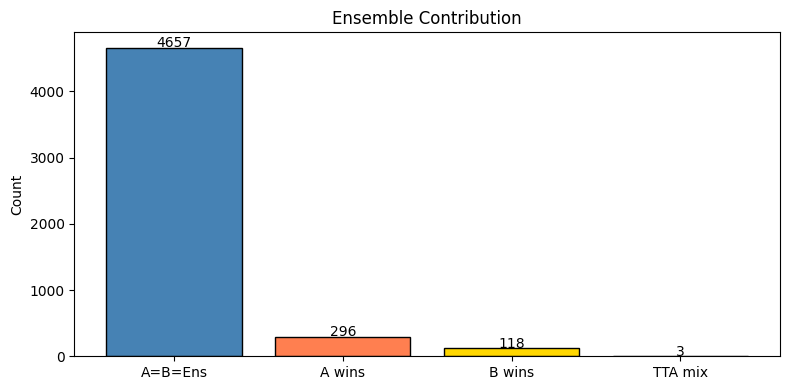

In [20]:
# 각 모델 단독 정답 vs 앙상블
pred_a_only = []
pred_b_only = []
for i in range(len(test_df)):
    pa, _ = all_probs_a[i]
    pb, _ = all_probs_b[i]
    pred_a_only.append(probs_to_answer(pa)[0])
    pred_b_only.append(probs_to_answer(pb)[0])

agree = sum(1 for a,b,e in zip(pred_a_only, pred_b_only, final_preds) if a==b==e)
disagree_a_wins = sum(1 for a,b,e in zip(pred_a_only, pred_b_only, final_preds) if a!=b and e==a)
disagree_b_wins = sum(1 for a,b,e in zip(pred_a_only, pred_b_only, final_preds) if a!=b and e==b)
disagree_other = sum(1 for a,b,e in zip(pred_a_only, pred_b_only, final_preds) if a!=b and e!=a and e!=b)

total = len(test_df)
print(f"모델 일치 (A=B=Ensemble): {agree} ({agree/total*100:.1f}%)")
print(f"불일치 → A 채택:          {disagree_a_wins} ({disagree_a_wins/total*100:.1f}%)")
print(f"불일치 → B 채택:          {disagree_b_wins} ({disagree_b_wins/total*100:.1f}%)")
print(f"불일치 → TTA 보정:        {disagree_other} ({disagree_other/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8,4))
labels = ["A=B=Ens", "A wins", "B wins", "TTA mix"]
vals = [agree, disagree_a_wins, disagree_b_wins, disagree_other]
ax.bar(labels, vals, color=["steelblue","coral","gold","gray"], edgecolor="black")
ax.set_title("Ensemble Contribution"); ax.set_ylabel("Count")
for i,v in enumerate(vals): ax.text(i, v+5, str(v), ha="center")
plt.tight_layout(); plt.show()

## 11. 제출 CSV

In [21]:
submission = pd.DataFrame({"id": test_df["id"], "answer": final_preds})
sub_path = os.path.join(DATA_ROOT, "submission_final_tta_ensemble.csv")
submission.to_csv(sub_path, index=False)
print(f"✅ Saved: {sub_path}")
print(submission["answer"].value_counts().sort_index())
print(f"Total: {len(submission)}")

✅ Saved: /content/drive/MyDrive/Colab Notebooks/submission_final_tta_ensemble.csv
answer
a    1211
b    1266
c    1284
d    1313
Name: count, dtype: int64
Total: 5074


## 12. Confidence 분포 시각화

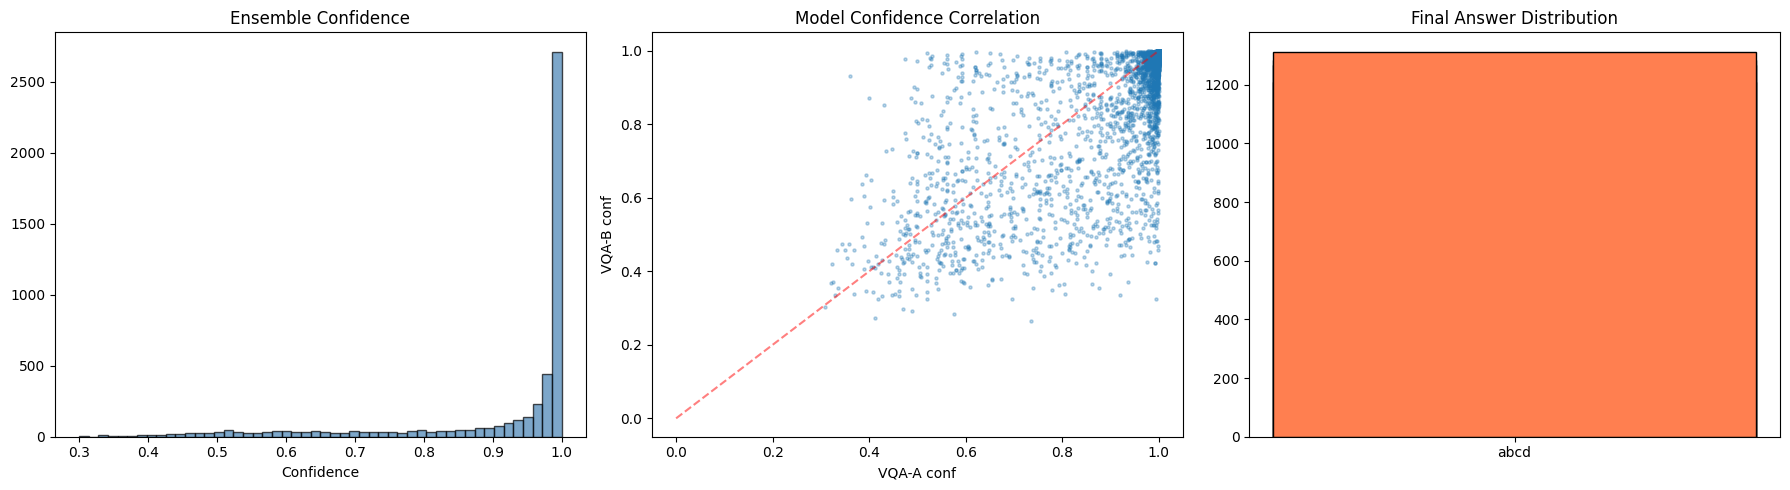

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(final_confs, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title("Ensemble Confidence"); axes[0].set_xlabel("Confidence")

# A vs B confidence
confs_a = [probs_to_answer(all_probs_a[i][0])[1] for i in range(len(test_df))]
confs_b = [probs_to_answer(all_probs_b[i][0])[1] for i in range(len(test_df))]
axes[1].scatter(confs_a, confs_b, alpha=0.3, s=5)
axes[1].set_xlabel("VQA-A conf"); axes[1].set_ylabel("VQA-B conf")
axes[1].set_title("Model Confidence Correlation")
axes[1].plot([0,1],[0,1],'r--',alpha=0.5)

ac = Counter(final_preds)
axes[2].bar('abcd', [ac.get(c,0) for c in 'abcd'], color='coral', edgecolor='black')
axes[2].set_title("Final Answer Distribution")
plt.tight_layout(); plt.show()

## 13. 마무리

In [23]:
torch.cuda.empty_cache(); gc.collect()
print(f"✅ 완료! 제출: {sub_path}")

✅ 완료! 제출: /content/drive/MyDrive/Colab Notebooks/submission_final_tta_ensemble.csv


## 참고

**파이프라인 요약:**
```
[Detection Phase]  Grounding DINO + Florence-2 → 크롭 캐싱 → 언로드
      ↓
[VQA-A Phase]  Qwen3-VL-32B (LoRA) × TTA(원본+반전) → logits 저장 → 언로드
      ↓
[VQA-B Phase]  Qwen3.5-27B × TTA(원본+반전) → logits 저장 → 언로드
      ↓
[Ensemble]  4개 logit 가중합산 → 최종 답
```

**TTA 전략:**
- 좌우반전(horizontal flip)만 사용 (재활용품은 좌우 대칭 무관)
- 반전 가중치 0.5 (원본의 절반)
- 총 4회 추론: VQA-A×2 + VQA-B×2

**가중치:**
- `W_VQA_A=1.0`: fine-tuned 도메인 모델 → 높은 신뢰
- `W_VQA_B=0.7`: 범용 VLM → 보완적
- `W_TTA=0.5`: 반전 결과 → 원본의 절반

**VRAM 관리:**
- 순차 로드/언로드로 A100 90GB 한 장에서 실행
- Detection (~4GB) → VQA-A (~40GB) → VQA-B (~56GB bf16)

**Qwen3.5-27B 특이사항:**
- `enable_thinking=False` 필수
- `AutoModelForImageTextToText` 클래스 사용
- transformers v5 (main branch) 필요